# Supervised Learning

This notebook use simple supervised learning to classify images into classes.

In [55]:
# install requirements

# if connected to colab

if 'google.colab' in str(get_ipython()):
  print('running on colab')
  !git clone https://github.com/ongarileonardo/galaxy_class.git
  %cd galaxy_class

%pip install --upgrade pip
%pip install -r requirements-learn.txt

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/henrysky/astroNN.git to /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-jx8lqicl
  Running command git clone --filter=blob:none --quiet https://github.com/henrysky/astroNN.git /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-jx8lqicl
  Resolved https://github.com/henrysky/astroNN.git to commit 6d947193f5a995c61266d3702b3a2df4643489f5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [56]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# import everything we need first
from keras import utils
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from astroNN.datasets import galaxy10
from astroNN.datasets.galaxy10 import galaxy10cls_lookup

In [57]:
# To load images and labels (will download automatically at the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = galaxy10.load_data()

/Users/leo/.astroNN/datasets/Galaxy10_DECals.h5 was found!


In [58]:
images.shape

(17736, 256, 256, 3)

In [59]:
# divide images and labels into training and test sets

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.4, random_state=42)

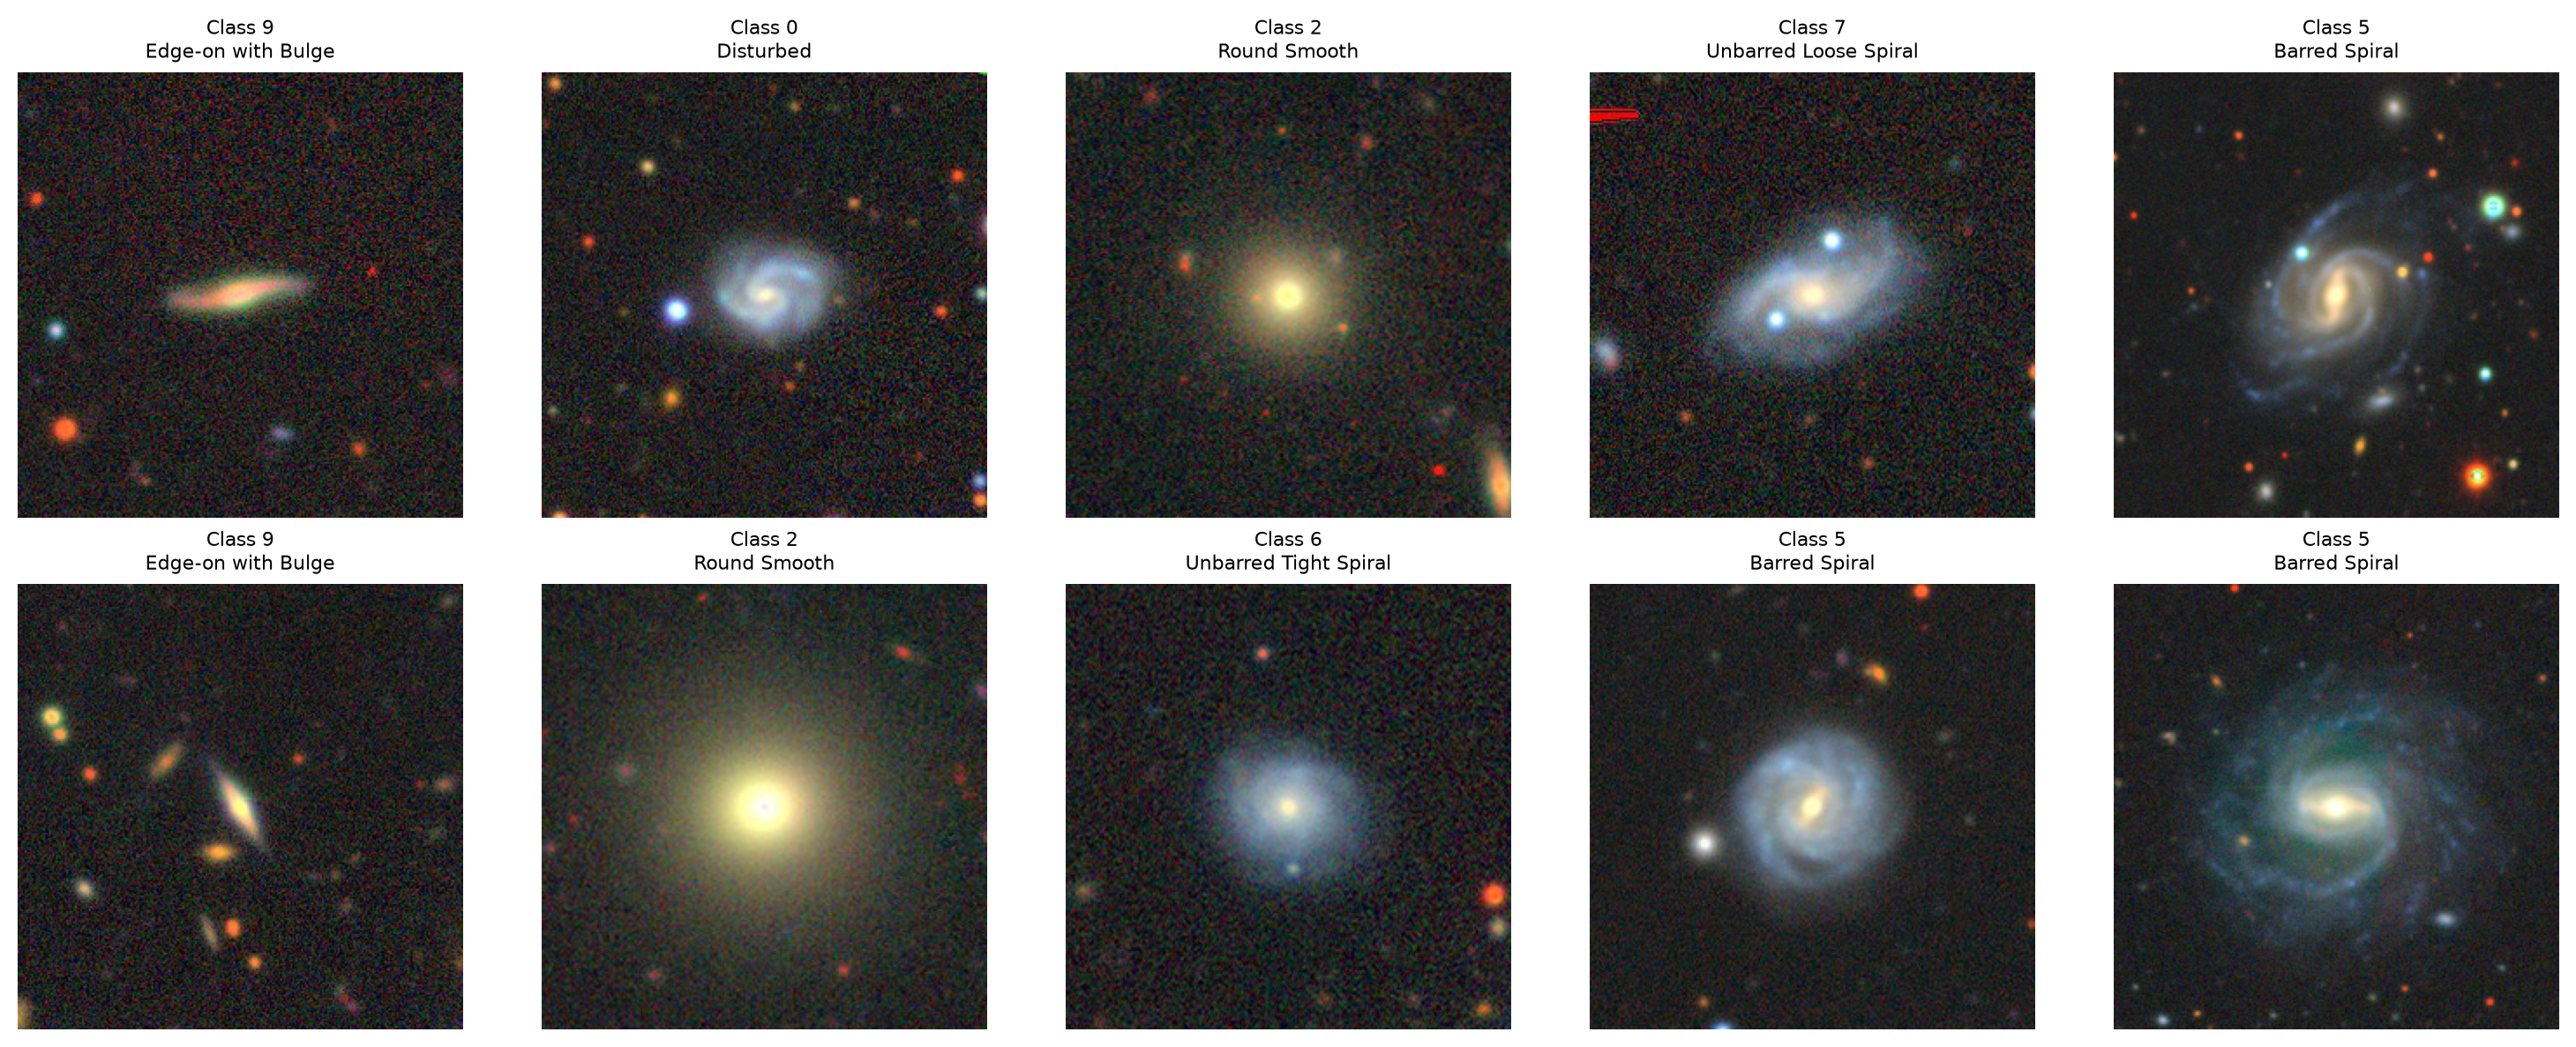

In [60]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, y_train.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i])
    ax.set_title(f"Class {y_train[i]}\n{galaxy10cls_lookup(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("original.pdf")
plt.show()

In [61]:
def center_crop(img, crop_size):
    h, w = img.shape[:2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

crop_size = 128
X_train_cropped = np.array([center_crop(img, crop_size) for img in X_train])
X_test_cropped = np.array([center_crop(img, crop_size) for img in X_test])

print(X_train_cropped.shape)

(10641, 128, 128, 3)


In [62]:
from PIL import Image
import numpy as np

X_train_gray = np.array([
    np.array(Image.fromarray(img).convert('L')) for img in X_train_cropped
])
X_test_gray = np.array([
    np.array(Image.fromarray(img).convert('L')) for img in X_test_cropped
])

print(X_train_gray.shape)

(10641, 128, 128)


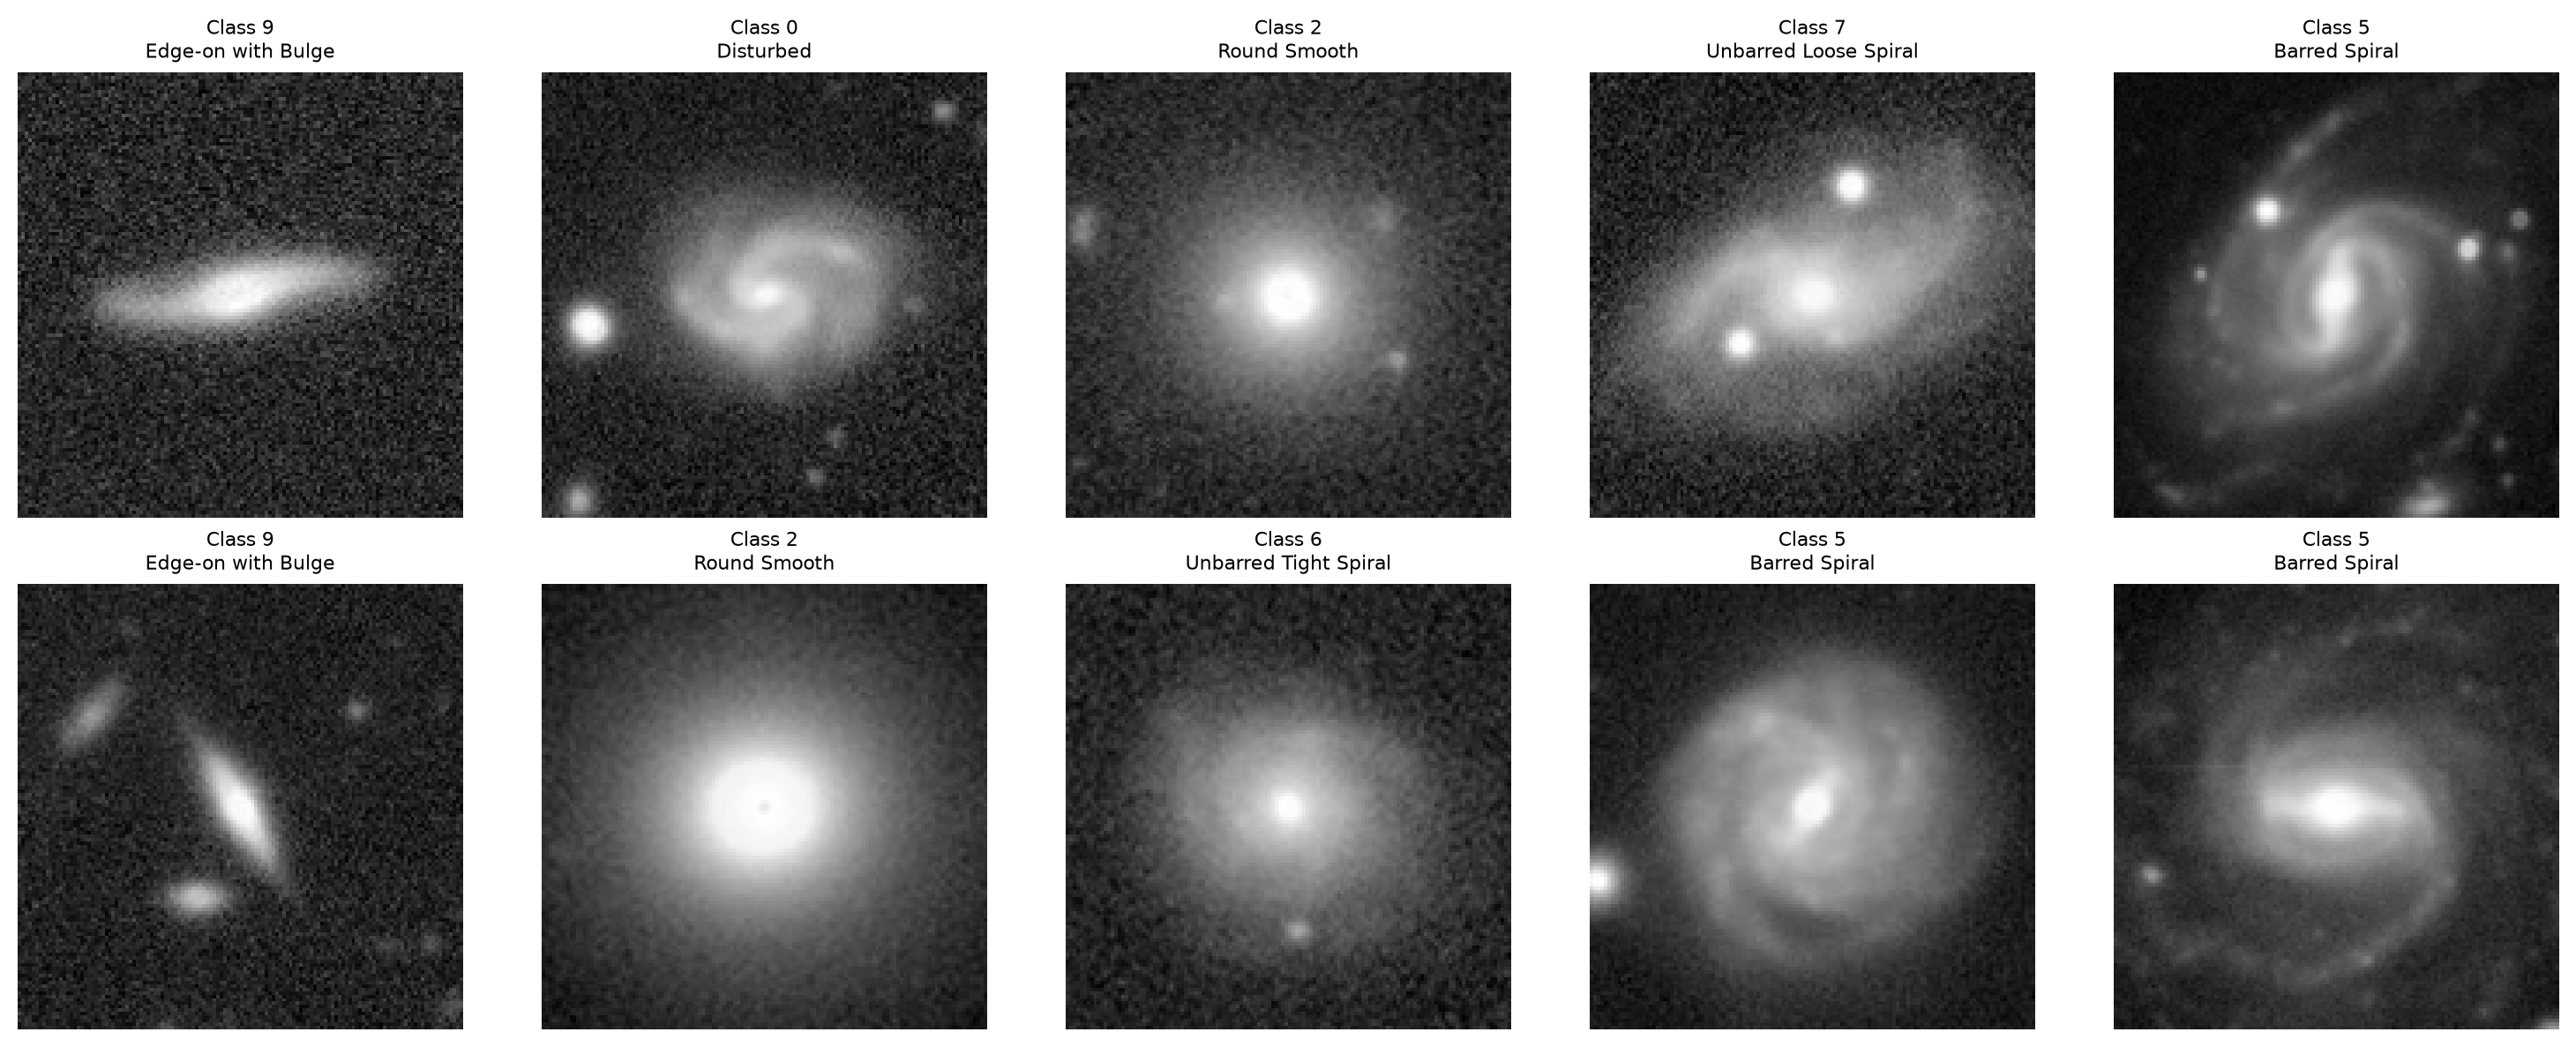

In [63]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_gray[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}\n{galaxy10cls_lookup(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data Cleaning

1. normalization (min-max)
2. normalization using percentiles
3. gaussian / bilateral filter
4. histogram equalization

In [64]:
# Min-max normalization (per-image)

X_min = X_train_gray.min(axis=(1,2), keepdims=True)  
X_max = X_train_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_train_gray - X_min) / (X_max - X_min + 1e-8)  

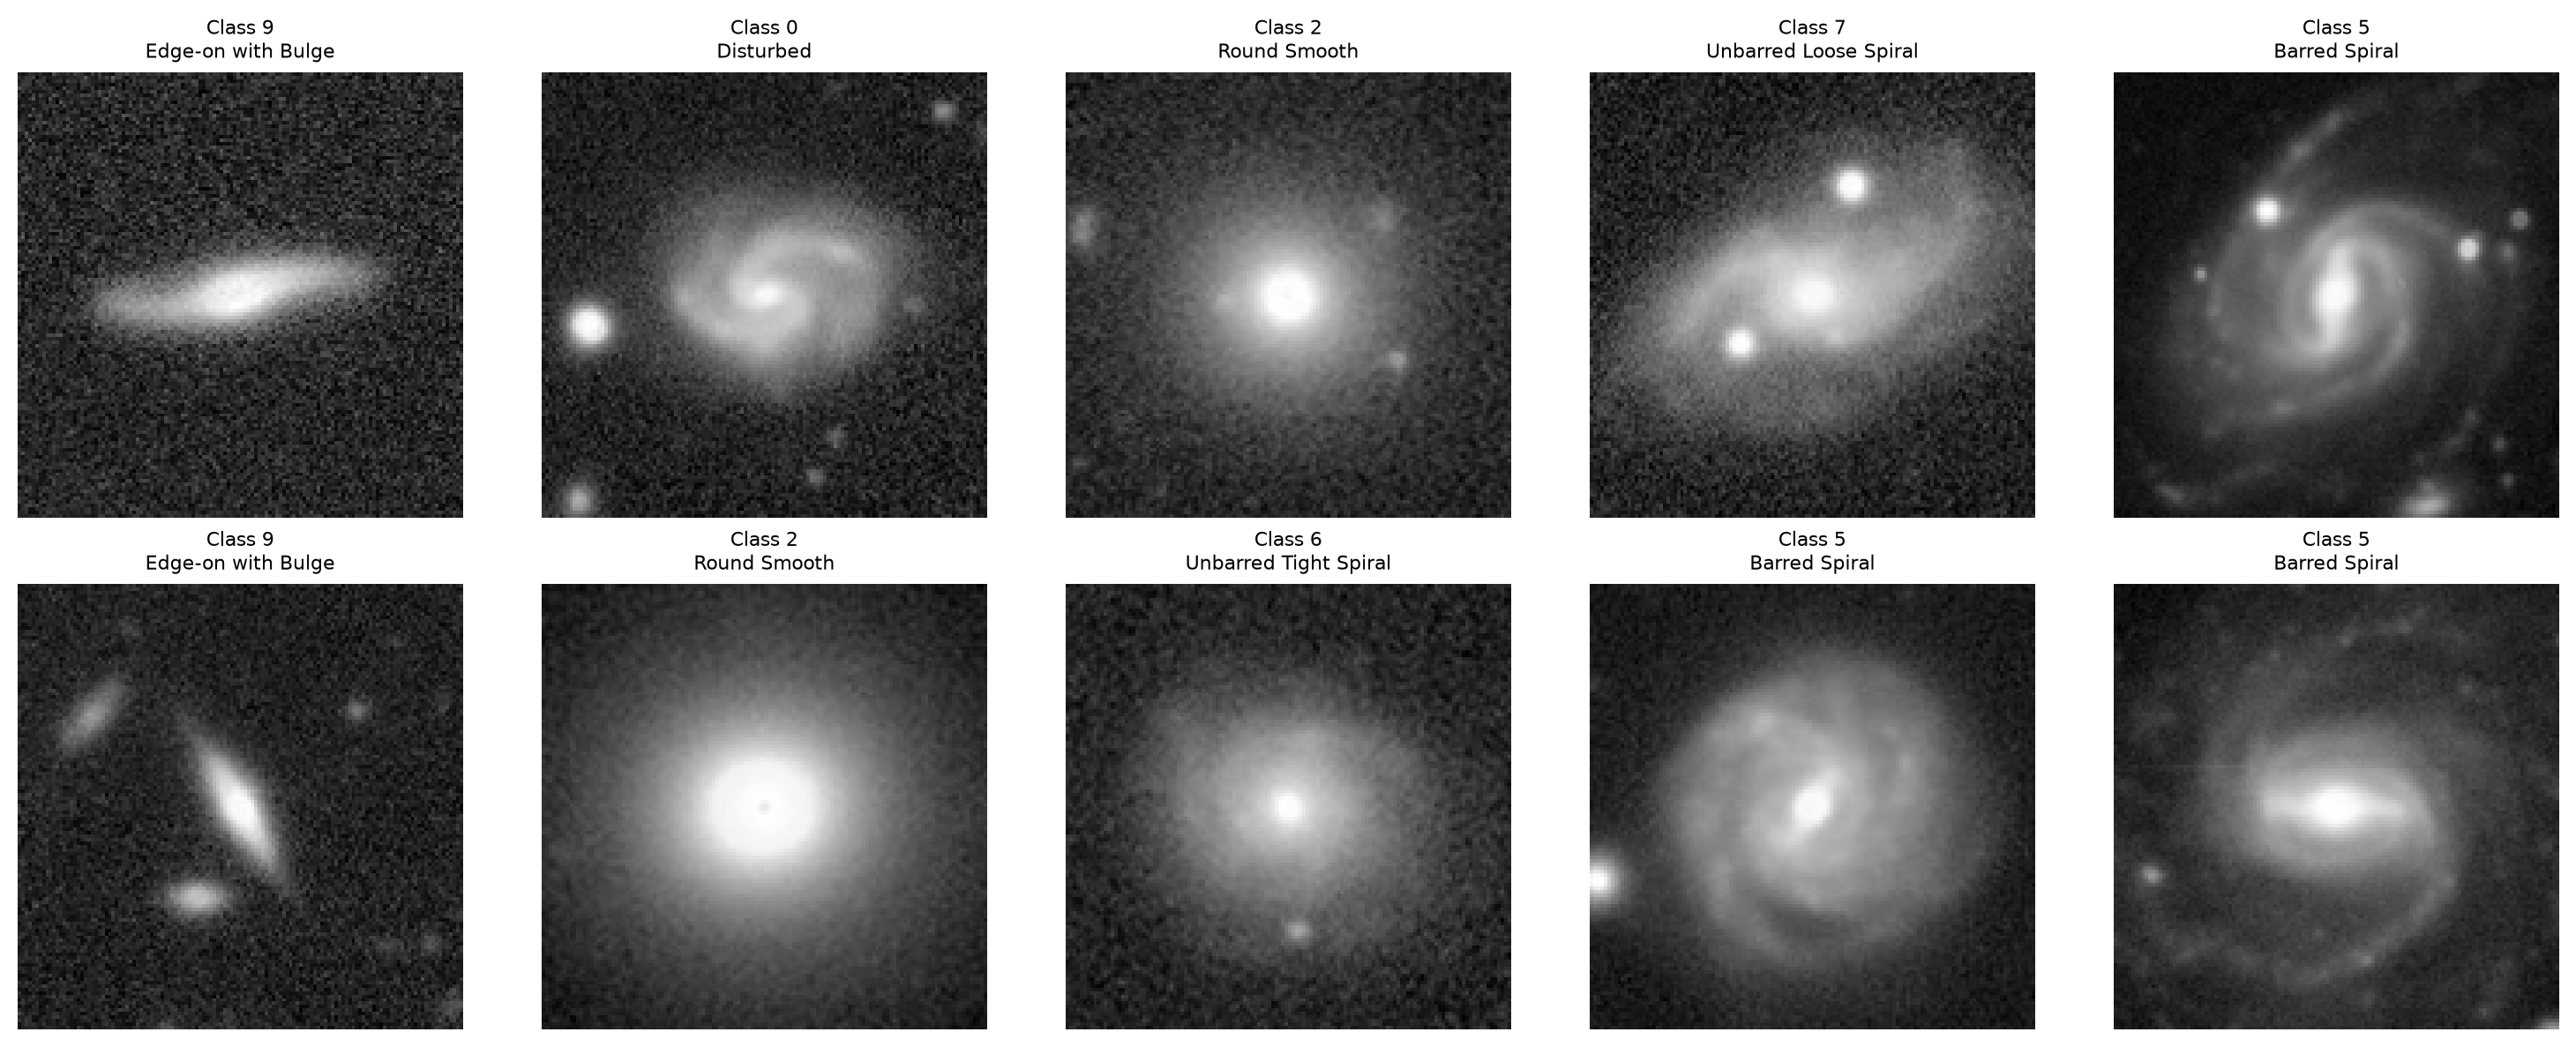

In [65]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_norm[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}\n{galaxy10cls_lookup(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("gray_cropped.pdf")
plt.show()

In [66]:
X_norm.shape

(10641, 128, 128)

In [67]:
# gaussian filter on images

from scipy.ndimage import gaussian_filter

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])

In [68]:
X_gauss.min(), X_gauss.max()

(0.0, 0.9999999999598393)

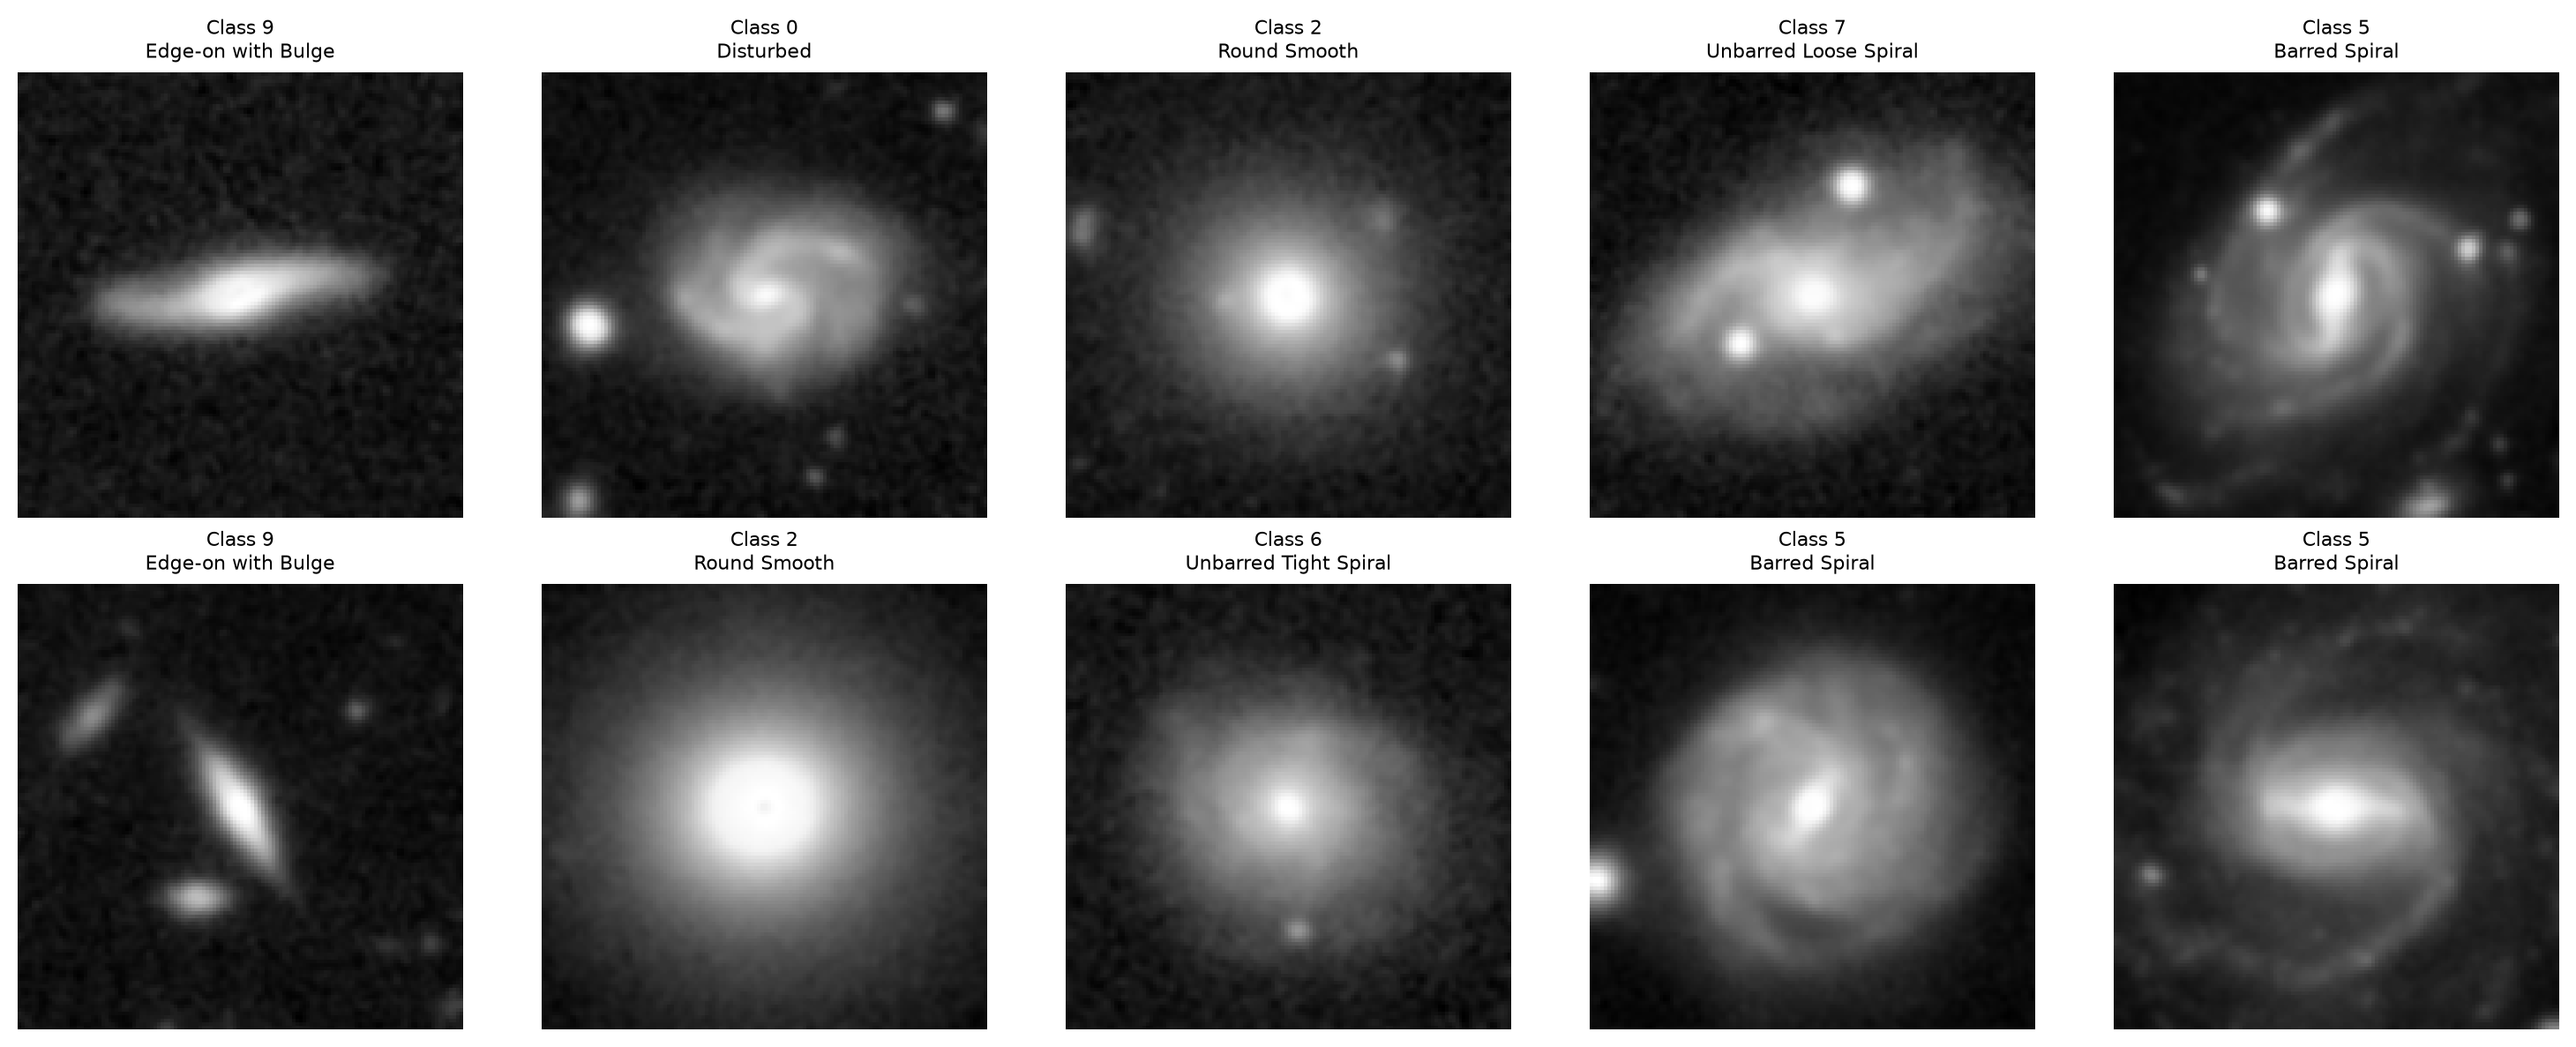

In [69]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_gauss[i], cmap="gray")
    ax.set_title(f"Class {y_train[i]}\n{galaxy10cls_lookup(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("gaussian_smooth.pdf")
plt.show()

In [70]:
# train a model on X_norm (without filters) and X_gauss

X_norm.shape, y_train.shape

((10641, 128, 128), (10641,))

In [71]:
# train a CNN model

import tensorflow as tf
from keras import layers, models

In [72]:

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
model = models.Sequential()

model.add(layers.Input(shape=(128, 128, 1)))

# block 1
model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# block 2
model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# block 3
model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

model.add(layers.Dense(10, activation='softmax'))

In [73]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [74]:
X_norm.shape

(10641, 128, 128)

In [75]:
X_flat = X_norm[..., np.newaxis]
y_labels = utils.to_categorical(y_train, 10)


In [76]:
X_flat.shape

(10641, 128, 128, 1)

In [77]:
history = model.fit(
    X_flat, y_labels,
    epochs=20,
    batch_size=128,
    shuffle=True
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 800ms/step - accuracy: 0.1348 - loss: 0.4120
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 747ms/step - accuracy: 0.2416 - loss: 0.2993
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 754ms/step - accuracy: 0.2945 - loss: 0.2877
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 75s 890ms/step - accuracy: 0.3427 - loss: 0.2742
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 766ms/step - accuracy: 0.3968 - loss: 0.2588
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 744ms/step - accuracy: 0.4271 - loss: 0.2471
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 759ms/step - accuracy: 0.4703 - loss: 0.2338
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 752ms/step - accuracy: 0.4978 - loss: 0.2225
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 750ms/step - accuracy: 0.5321 - loss: 0.2123
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 62s 736ms/step - accuracy: 0.5689 - loss: 0.2006
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 62s 739ms/step - accuracy: 0.5819 - loss: 0.1947
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 58

In [78]:
y = model.predict(X_flat)

333/333 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step


In [79]:
y_labels = (y > 0.5).astype(int)

In [80]:
y_labels = np.argmax(y_labels, axis=1)

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_labels, y_train)

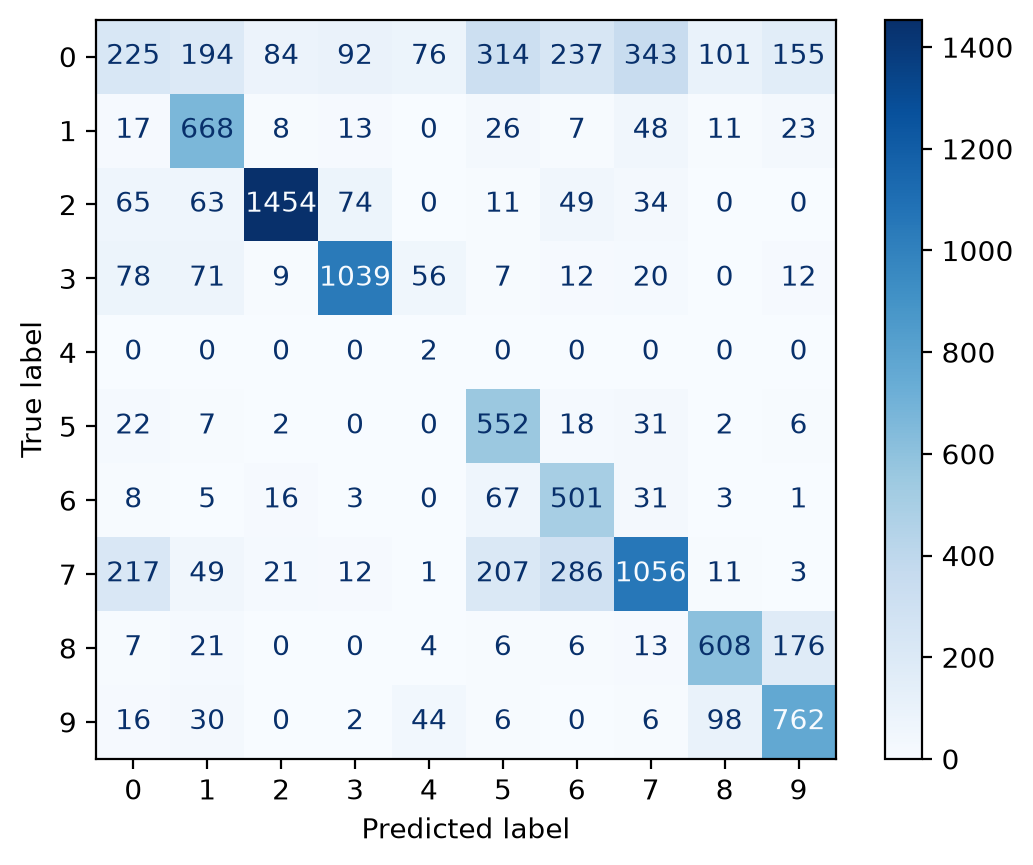

In [82]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()